In [5]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import sqlite3
import pandas as pd
import numpy as np

# 1. Crear base de datos SQLite relacional en memoria/disco
conn = sqlite3.connect('empresa_retail_real.db')
cursor = conn.cursor()

# 2. Crear tablas dimensionales (SQL puro)
cursor.executescript('''
DROP TABLE IF EXISTS sucursales;
DROP TABLE IF EXISTS productos;
DROP TABLE IF EXISTS ventas_raw;

CREATE TABLE sucursales (
    sucursal_id INTEGER PRIMARY KEY,
    nombre_sucursal TEXT,
    provincia TEXT
);

CREATE TABLE productos (
    producto_id INTEGER PRIMARY KEY,
    nombre_producto TEXT,
    categoria TEXT,
    precio_costo REAL
);

INSERT INTO sucursales VALUES 
(1, 'Sucursal Bahía Centro', 'Buenos Aires'),
(2, 'Sucursal Córdoba Shopping', 'Córdoba'),
(3, 'Sucursal Rosario Norte', 'Santa Fe');

INSERT INTO productos VALUES 
(101, 'Filtro Aceite MWM', 'Repuestos', 4500.0),
(102, 'Batería 12V 75Ah', 'Electricidad', 38000.0),
(103, 'Aceite 2T Sintético 1L', 'Insumos', 3200.0),
(104, 'Kit Cadena Distribución', 'Repuestos', 22000.0);
''')
conn.commit()

# 3. Generar dataset masivo de transacciones con inconsistencias (ETL/EDA)
np.random.seed(42)
n_filas = 500

fechas = pd.date_range(start='2025-01-01', end='2026-03-30', periods=n_filas)
fechas_con_error = [f.strftime('%Y-%m-%d') if i % 10 != 0 else f.strftime('%d/%m/%Y') for i, f in enumerate(fechas)]

df_ventas = pd.DataFrame({
    'venta_id': range(1000, 1000 + n_filas),
    'fecha': fechas_con_error,
    'sucursal_id': np.random.choice([1, 2, 3, 99], size=n_filas, p=[0.45, 0.35, 0.15, 0.05]), # 99: id inexistente (probar LEFT JOIN)
    'producto_id': np.random.choice([101, 102, 103, 104], size=n_filas),
    'unidades_vendidas': np.random.choice([1, 2, 3, 5, 10, np.nan], size=n_filas, p=[0.5, 0.25, 0.15, 0.05, 0.03, 0.02]), # con nulos
    'monto_total_usd': np.random.normal(loc=120, scale=35, size=n_filas).round(2),
    'canal_venta': np.random.choice([' Local Comercial ', 'LOCAL COMERCIAL', 'e-commerce', 'E-COMMERCE ', 'mayorista'], size=n_filas) # inconsistencia de texto
})

# Cargar transacciones a SQL
df_ventas.to_sql('ventas_raw', conn, if_exists='replace', index=False)

print("✅ Base de datos relacional 'empresa_retail_real.db' creada exitosamente.")
print("Tablas disponibles: 'sucursales', 'productos', 'ventas_raw'.")

✅ Base de datos relacional 'empresa_retail_real.db' creada exitosamente.
Tablas disponibles: 'sucursales', 'productos', 'ventas_raw'.


In [7]:
# Consulta SQL Relacional para traer datos unificados
query_sql = '''
SELECT 
    v.venta_id,
    v.fecha,
    v.canal_venta,
    v.unidades_vendidas,
    v.monto_total_usd,
    p.nombre_producto,
    p.categoria,
    p.precio_costo,
    COALESCE(s.nombre_sucursal, 'Sucursal no Asignada') AS sucursal,
    COALESCE(s.provincia, 'Desconocida') AS provincia
FROM ventas_raw v
LEFT JOIN productos p ON v.producto_id = p.producto_id
LEFT JOIN sucursales s ON v.sucursal_id = s.sucursal_id
'''

df_consolidado = pd.read_sql_query(query_sql, conn)

# --- PROCESO DE LIMPIEZA (ETL / EDA) ---
# 1. Estandarización de texto en Canal de Venta
df_consolidado['canal_venta'] = df_consolidado['canal_venta'].str.strip().str.title()

# 2. Normalización de Fechas a Datetime
df_consolidado['fecha'] = pd.to_datetime(df_consolidado['fecha'], format='mixed')

# 3. Tratamiento de Valores Nulos (Imputación con la mediana)
mediana_unidades = df_consolidado['unidades_vendidas'].median()
df_consolidado['unidades_vendidas'] = df_consolidado['unidades_vendidas'].fillna(mediana_unidades)

# 4. Eliminación de inconsistencias (Monto negativo o nulo si lo hubiera)
df_consolidado = df_consolidado[df_consolidado['monto_total_usd'] > 0]

print("--- MUESTRA DEL DATASET CONSOLIDADO Y LIMPIO ---")
df_consolidado.head()

--- MUESTRA DEL DATASET CONSOLIDADO Y LIMPIO ---


,venta_id,fecha,canal_venta,unidades_vendidas,monto_total_usd,nombre_producto,categoria,precio_costo,sucursal,provincia
0,1000,2025-01-01,Local Comercial,1.0,116.86,Batería 12V 75Ah,Electricidad,38000.0,Sucursal Bahía Centro,Buenos Aires
1,1001,2025-01-01,Local Comercial,5.0,170.40,Aceite 2T Sintético 1L,Insumos,3200.0,Sucursal no Asignada,Desconocida
2,1002,2025-01-02,E-Commerce,2.0,96.33,Filtro Aceite MWM,Repuestos,4500.0,Sucursal Córdoba Shopping,Córdoba
3,1003,2025-01-03,Local Comercial,1.0,183.03,Filtro Aceite MWM,Repuestos,4500.0,Sucursal Córdoba Shopping,Córdoba
4,1004,2025-01-04,Local Comercial,1.0,118.59,Filtro Aceite MWM,Repuestos,4500.0,Sucursal Bahía Centro,Buenos Aires


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Feature Engineering (Crear características numéricas para el modelo)
df_ml = df_consolidado.copy()
df_ml['mes'] = df_ml['fecha'].dt.month
df_ml['dia_semana'] = df_ml['fecha'].dt.dayofweek

# Convertir variables categóricas en dummies (One-Hot Encoding)
df_ml_dummies = pd.get_dummies(df_ml[['categoria', 'canal_venta', 'provincia']], drop_first=True)

# Definir matriz de entrada (X) y variable objetivo (y: Unidades Vendidas)
X = pd.concat([df_ml[['precio_costo', 'monto_total_usd', 'mes', 'dia_semana']], df_ml_dummies], axis=1)
y = df_ml['unidades_vendidas']

# 2. División Entrenamiento / Evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar Modelo de Predicción de Demanda
modelo_demanda = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_demanda.fit(X_train, y_train)

# 4. Evaluación del modelo
predicciones = modelo_demanda.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)

print("==================================================")
print("📊 EVALUACIÓN DEL MODELO DE PREDICCIÓN DE DEMANDA")
print(f"Error Absoluto Medio (MAE): {mae:.2f} unidades")
print("==================================================")

📊 EVALUACIÓN DEL MODELO DE PREDICCIÓN DE DEMANDA
Error Absoluto Medio (MAE): 1.34 unidades


C:\Users\CONECTIA BA\AppData\Local\Temp\ipykernel_13040\3437577494.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


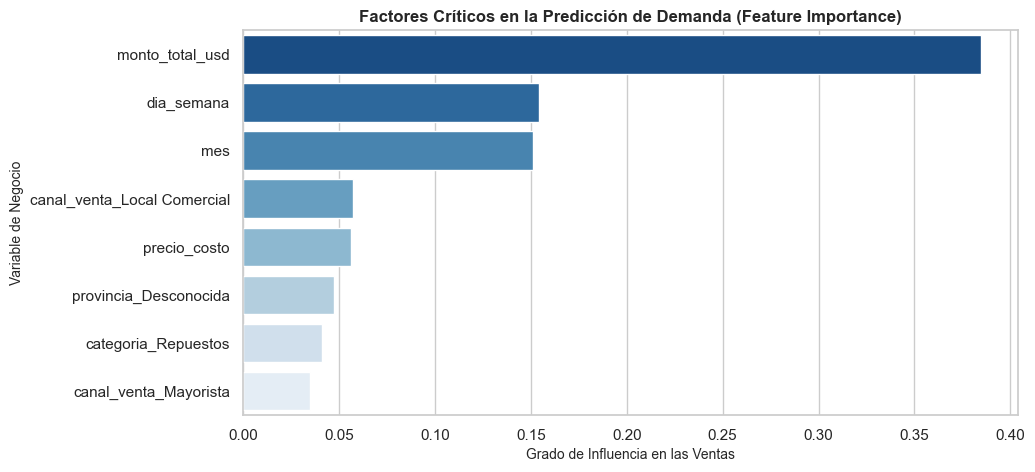

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer la importancia de cada variable desde el algoritmo Random Forest
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_demanda.feature_importances_
}).sort_values(by='Importancia', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.barplot(
    data=importancias.head(8), 
    x='Importancia', 
    y='Variable', 
    palette='Blues_r'
)

plt.title('Factores Críticos en la Predicción de Demanda (Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Grado de Influencia en las Ventas', fontsize=10)
plt.ylabel('Variable de Negocio', fontsize=10)
plt.show()